# Week 3 — Clustering

## Adult Income Dataset

This notebook presents the clustering analysis performed on the cleaned Adult Income Dataset.

The objective of this analysis is to apply unsupervised learning techniques to identify groups of observations with similar characteristics using numerical features from the dataset.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [72]:
df = pd.read_csv("/content/adult_cleaned.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (45175, 15)


In [73]:
numerical_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

print("Numerical features selected:")
print(numerical_features)

Numerical features selected:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [74]:
X = df[numerical_features]

print("Clustering data created.")
print("Shape:", X.shape)

Clustering data created.
Shape: (45175, 6)


In [75]:
print(X.describe())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  45175.000000  4.517500e+04   45175.000000  45175.000000  45175.000000   
mean      38.556170  1.897388e+05      10.119314   1102.576270     88.687593   
std       13.215349  1.056524e+05       2.551740   7510.249876    405.156611   
min       17.000000  1.349200e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.173925e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783120e+05      10.000000      0.000000      0.000000   
75%       47.000000  2.379030e+05      13.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    45175.000000  
mean        40.942512  
std         12.007730  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [76]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed.
Scaled data shape: (45175, 6)


## Determining the Number of Clusters

K-Means clustering requires the number of clusters to be specified in advance. To determine a suitable number of clusters, different values of K will be tested.

The Elbow Method will be used to compare the within-cluster variation for different values of K. This analysis will help identify a suitable clustering configuration based on the observed change in inertia.

In [77]:
inertia_values = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print("Inertia values calculated.")
print(inertia_values)

Inertia values calculated.
[226590.18760101486, 193463.06477270005, 153843.03283790904, 131985.0270897979, 114838.60492497671, 103767.35428103575, 94798.46826200683, 88032.38719216255, 83438.46065669395]


## Elbow Method

The Elbow Method is used to examine how inertia changes as the number of clusters increases. The value of K where the reduction in inertia begins to slow down can provide an indication of a suitable number of clusters.

The resulting plot will be examined to identify the point where adding additional clusters provides progressively smaller reductions in inertia.

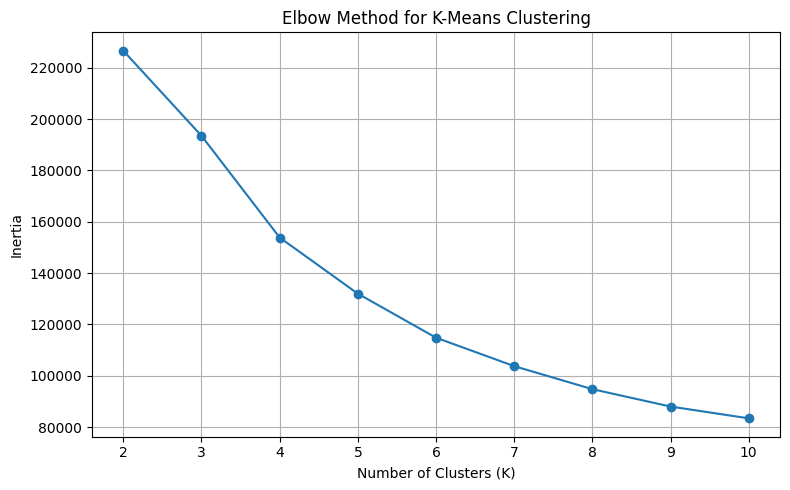

In [78]:
k_values = range(2, 11)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Clustering")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()

plt.savefig("/content/elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

## Silhouette Score Analysis

The Silhouette Score is used as a second measure for evaluating the quality of clustering.

It measures how similar each observation is to its own cluster compared with other clusters. Higher silhouette scores generally indicate better separation between clusters.

Silhouette scores will be calculated for different values of K and compared with the Elbow Method results.

In [79]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

print("Silhouette scores calculated.")
print(silhouette_scores)

Silhouette scores calculated.
[np.float64(0.5095041550725297), np.float64(0.1936229691237802), np.float64(0.20325035862419247), np.float64(0.21930225378193294), np.float64(0.22864474662873985), np.float64(0.2429734082133223), np.float64(0.24273618813702927), np.float64(0.24567342864186836), np.float64(0.2413475027917453)]


In [80]:
sample_size = 10000

X_sample = X_scaled[np.random.RandomState(42).choice(
    X_scaled.shape[0],
    sample_size,
    replace=False
)]

print("Sample created.")
print("Sample shape:", X_sample.shape)

Sample created.
Sample shape: (10000, 6)


In [81]:
sample_silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(X_sample, cluster_labels)
    sample_silhouette_scores.append(score)

print("Silhouette scores calculated.")
print(sample_silhouette_scores)

Silhouette scores calculated.
[np.float64(0.5111415328100778), np.float64(0.19438224133533955), np.float64(0.2024899834590818), np.float64(0.21826184947011143), np.float64(0.22979597969023008), np.float64(0.2438984741814559), np.float64(0.24279847974993798), np.float64(0.24590932835333237), np.float64(0.23771567076462707)]


## Silhouette Score Visualization

The silhouette scores are visualized for the tested cluster counts from K = 2 to K = 10.

The results show that K = 2 has the highest silhouette score among the tested configurations. The remaining configurations have substantially lower scores, although their scores gradually improve across several higher values of K.

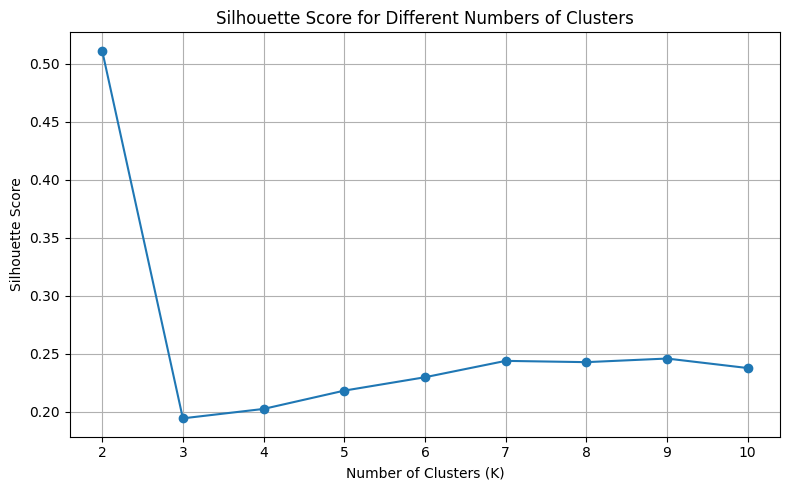

In [82]:
k_values = range(2, 11)

plt.figure(figsize=(8, 5))
plt.plot(k_values, sample_silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()

plt.savefig("/content/silhouette_score.png", dpi=300, bbox_inches="tight")

plt.show()

## Selection of the Number of Clusters

The Elbow Method showed that the reduction in inertia became less pronounced around K = 4 to K = 5. However, the Silhouette Score provided a clearer separation between the tested configurations.

The highest Silhouette Score was obtained at K = 2, with a score of approximately 0.5111. The scores for K = 3 through K = 10 were substantially lower, ranging from approximately 0.1944 to 0.2459.

Based on the combined analysis, K = 2 was selected for the final K-Means clustering model. The Elbow Method results are also retained in the analysis to provide transparency about the model-selection process.

## Final K-Means Clustering Model

Based on the Elbow Method and Silhouette Score analysis, K = 2 was selected for the final clustering model.

The K-Means algorithm is now fitted to the complete scaled dataset using two clusters. Each observation will be assigned to one of the resulting clusters.

In [83]:
final_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

print("Final K-Means model completed.")
print("Cluster counts:")
print(df["cluster"].value_counts().sort_index())

Final K-Means model completed.
Cluster counts:
cluster
0     2098
1    43077
Name: count, dtype: int64


## Cluster Profile Analysis

After assigning each observation to a cluster, the numerical features will be summarized separately for each cluster.

This comparison will help identify how the clusters differ in terms of age, education level, working hours, capital gains, capital losses, and other numerical characteristics.

In [84]:
cluster_summary = df.groupby("cluster")[numerical_features].mean()

print("Average feature values by cluster:")
print(cluster_summary)

Average feature values by cluster:
               age         fnlwgt  education-num  capital-gain  capital-loss  \
cluster                                                                        
0        41.776930  188121.709724      11.032888      0.000000   1898.044328   
1        38.399308  189817.556306      10.074820   1156.275576      0.565615   

         hours-per-week  
cluster                  
0             43.732602  
1             40.806625  


## Cluster Profile Visualization

The average numerical feature values for the two clusters are visualized to make the differences between their profiles easier to compare.

Because the numerical features have different units and scales, the visualization uses the standardized cluster means rather than the original feature values.

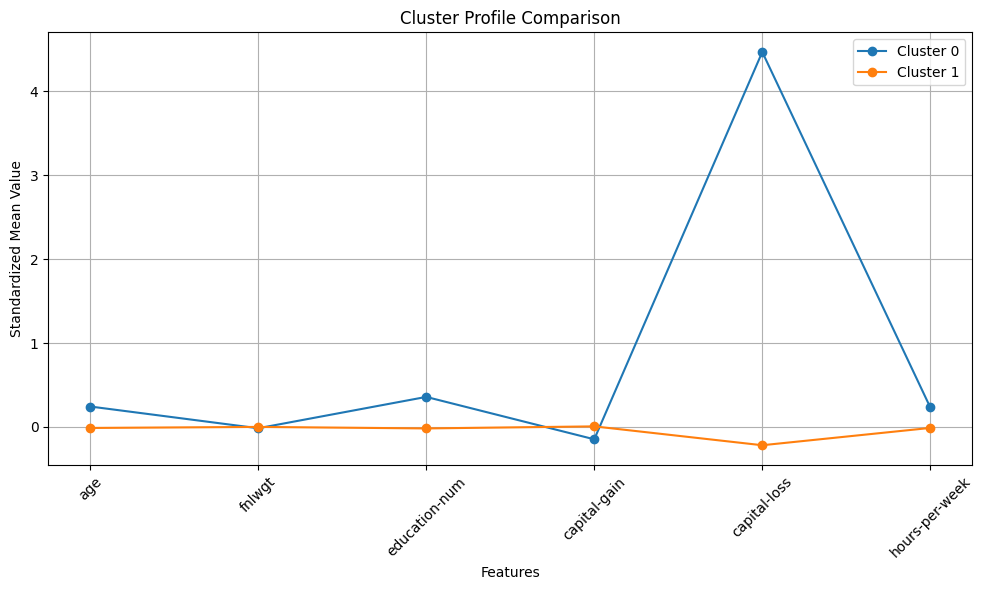

In [85]:
cluster_means = df.groupby("cluster")[numerical_features].mean()

cluster_means_scaled = pd.DataFrame(
    scaler.transform(cluster_means),
    columns=numerical_features,
    index=cluster_means.index
)

plt.figure(figsize=(10, 6))

for cluster in cluster_means_scaled.index:
    plt.plot(
        numerical_features,
        cluster_means_scaled.loc[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.xlabel("Features")
plt.ylabel("Standardized Mean Value")
plt.title("Cluster Profile Comparison")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("/content/cluster_profile_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

## Income Distribution Across Clusters

The income variable was not used as an input feature during clustering. It is now examined separately to understand how the discovered clusters are distributed across the income categories.

This post-clustering comparison does not influence the K-Means model. It is used only to help interpret the resulting clusters.

In [86]:
income_cluster_table = pd.crosstab(
    df["cluster"],
    df["income"],
    normalize="index"
) * 100

print("Income distribution within each cluster (%):")
print(income_cluster_table.round(2))

Income distribution within each cluster (%):
income   <=50K   >50K
cluster              
0        47.76  52.24
1        76.54  23.46


## Income Distribution by Cluster

The income composition of each cluster is visualized using percentages.

This visualization is used only for post-clustering interpretation. The income variable was not included as an input to the K-Means algorithm.

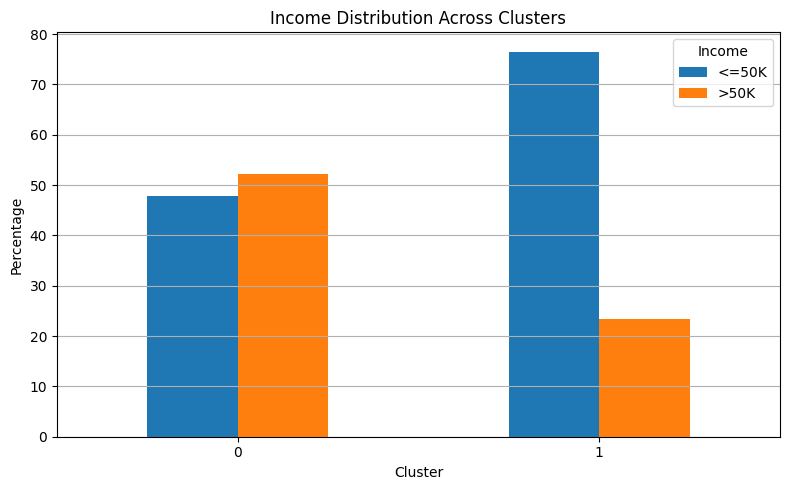

In [87]:
income_cluster_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.title("Income Distribution Across Clusters")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("/content/income_distribution_across_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

In [88]:
from google.colab import files

files.download("/content/elbow_method.png")
files.download("/content/silhouette_score.png")
files.download("/content/cluster_profile_comparison.png")
files.download("/content/income_distribution_across_clusters.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
import os

image_files = [
    "/content/elbow_method.png",
    "/content/silhouette_score.png",
    "/content/cluster_profile_comparison.png",
    "/content/income_distribution_across_clusters.png"
]

for file in image_files:
    print(os.path.basename(file), "→", "Found" if os.path.exists(file) else "Missing")

elbow_method.png → Found
silhouette_score.png → Found
cluster_profile_comparison.png → Found
income_distribution_across_clusters.png → Found


In [90]:
import joblib

joblib.dump(final_kmeans, "/content/kmeans_clustering_model.pkl")

print("K-Means model saved successfully.")

K-Means model saved successfully.


In [91]:
from google.colab import files

files.download("/content/kmeans_clustering_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
import joblib

model = joblib.load("kmeans_clustering_model.pkl")

print(model)

KMeans(n_clusters=2, n_init=10, random_state=42)
